In [35]:
import pandas as pd
import matplotlib.pyplot as plt
import onnxruntime as ort
import numpy as np

In [36]:
def compute_power_w(df_power_sub: pd.DataFrame, df_obs: pd.DataFrame = None) -> tuple[float, float]:
    energy_j = 0.0
    gpu_power_cols = [col for col in df_power_sub.columns if col.startswith("GPU_") and col.endswith("_power_w")]

    # zero out energy during idle times in df_obs, i.e. only keep compute times
    if df_obs is not None:
        idle_start_times = df_obs['start_times'] + df_obs['step_with_batch_queue_time_ms'] / 1000.0
        idle_end_times = df_obs['start_times'].shift(-1).fillna(df_obs['now'].max())
        for start, end in zip(idle_start_times, idle_end_times):
            df_power_sub.loc[(df_power_sub['Timestamp'] >= start+0.1) & (df_power_sub['Timestamp'] <= end+0.1), gpu_power_cols] = 0.0

    for col in gpu_power_cols:
        energy_j += np.trapezoid(df_power_sub[col], df_power_sub['Timestamp'])

    if df_obs is None:
        compute_duration = df_power_sub['Timestamp'].max() - df_power_sub['Timestamp'].min()
    else:
        compute_duration = df_obs['step_with_batch_queue_time_ms'].sum() / 1000.0
    return energy_j / compute_duration, energy_j


def get_power_async(path):
    df_stats = pd.read_csv(path + '/engine_0.csv')
    df_power = pd.read_csv(path + '/power_log.csv')

    # drop empty rows first
    df_stats['num_prompt_tokens_reqs_evald'] = df_stats['num_prompt_tokens_reqs'].apply(eval)
    df_stats = df_stats[df_stats['num_prompt_tokens_reqs_evald'].apply(lambda x: len(x) > 0)].copy()

    df_power  = df_power[(df_power['Timestamp'] >= df_stats['now'].min()+0.1) & (df_power['Timestamp'] <= df_stats['now'].max()+0.1)]

    # get power
    power, energy = compute_power_w(df_power)
    energy = energy / len(df_stats)
    return power, energy

def get_power_no_async(path):
    df_stats = pd.read_csv(path + '/engine_0.csv')
    df_power = pd.read_csv(path + '/power_log.csv')

    # drop empty rows first
    df_stats['num_prompt_tokens_reqs_evald'] = df_stats['num_prompt_tokens_reqs'].apply(eval)
    df_stats = df_stats[df_stats['num_prompt_tokens_reqs_evald'].apply(lambda x: len(x) > 0)].copy()
    # then do shift of gpu times
    df_stats.loc[:, "step_with_batch_queue_time_ms"] = df_stats["step_with_batch_queue_time_ms_1_iters_delay"].shift(-1)
    df_stats['start_times'] = df_stats['now'] - df_stats['step_with_batch_queue_time_ms'] / 1000.0

    # get power
    power, energy = compute_power_w(df_power, df_stats)
    energy = energy / len(df_stats)
    return power, energy

def get_power_real_run(path):
    df_stats = pd.read_csv(path + '/engine_0.csv')
    df_power = pd.read_csv(path + '/power_log.csv')

    # drop empty rows first
    df_stats['num_prompt_tokens_reqs_evald'] = df_stats['num_prompt_tokens_reqs'].apply(eval)
    df_stats = df_stats[df_stats['num_prompt_tokens_reqs_evald'].apply(lambda x: len(x) > 0)].copy()
    # then do shift of gpu times
    df_stats.loc[:, "step_with_batch_queue_time_ms"] = df_stats["step_with_batch_queue_time_ms_1_iters_delay"].shift(-1)

    df_stats['start_times'] = df_stats['now'] - df_stats['step_with_batch_queue_time_ms'] / 1000.0

    real_power_w = []
    real_energy_j = []
    for row in df_stats.itertuples():
        # get real power
        start_time = row.start_times
        end_time = row.now
        df_power_sub = df_power[(df_power['Timestamp'] >= start_time+0.1) & (df_power['Timestamp'] <= end_time+0.1)]
        df_obs = df_stats[(df_stats['start_times'] >= start_time) & (df_stats['start_times'] <= end_time)]
        power_w, energy_j = compute_power_w(df_power_sub, df_obs)
        real_power_w.append(power_w)
        real_energy_j.append(energy_j)
    real_power_w = real_power_w[:-1]
    print(real_power_w)
    real_energy_j = real_energy_j[:-1]
    plot_power_hist(real_power_w, "Real Run Power")
    plot_power_hist(real_energy_j, "Real Run Energy")
    return np.mean(real_power_w), np.mean(real_energy_j)

def plot_power_hist(power_list, title):
    plt.figure()
    plt.hist(power_list, bins=20, color='blue', alpha=0.7)
    plt.title(title)
    plt.ylabel('Frequency')
    plt.grid(axis='y', alpha=0.75)
    plt.show()

[np.float64(379.39790187806676), np.float64(367.32076233610974), np.float64(328.55308192624324), np.float64(355.8998511941601), np.float64(315.9179009960897), np.float64(357.05748101063904), np.float64(355.9006125115614), np.float64(557.6103452422684), np.float64(336.2719474115679), np.float64(445.979018812729), np.float64(447.10573500459964), np.float64(367.8499700425986), np.float64(564.3103809490373), np.float64(310.8576119759896), np.float64(372.55265488343395), np.float64(733.4259300971647), np.float64(250.0343461024321), np.float64(250.478610542018), np.float64(553.9166647819517), np.float64(507.1539433833072), np.float64(448.0686899539312), np.float64(488.0672556032955), np.float64(489.43630540864234), np.float64(283.10355170696386), np.float64(302.16293327559526), np.float64(607.5923881086742), np.float64(778.8110677672896), np.float64(582.6630990819637), np.float64(436.5936236636268), np.float64(335.67142377229646), np.float64(536.0982573326133), np.float64(433.52354556268534)

/tmp/ipykernel_497800/3542002045.py:19: RuntimeWarning: invalid value encountered in scalar divide
  return energy_j / compute_duration, energy_j


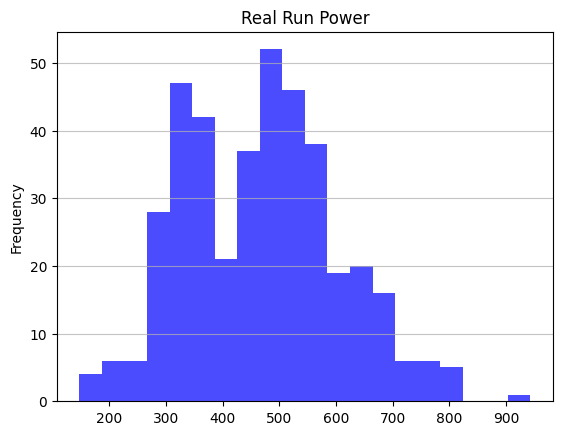

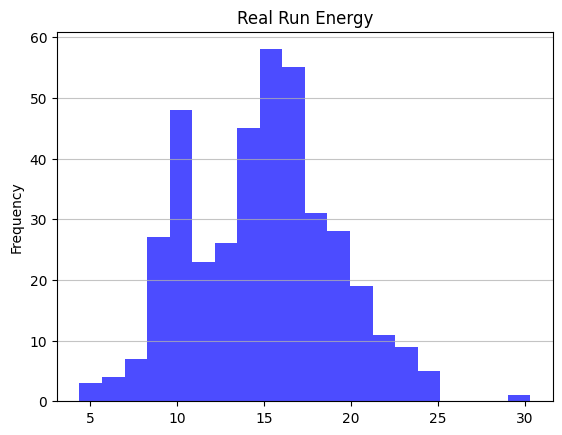

Power and Energy Results for len 128:
Async Power, energy: (np.float64(1163.6266325258293), np.float64(58.047759639742594)) W
No Async Power, energy: (np.float64(1534.9549435085828), np.float64(45.788856423934824)) W
Real Run Power, energy: (np.float64(468.11714859329714), np.float64(14.898836571978928)) W


In [37]:
async_p = get_power_async("/export2/obasit/ClusterLevelServing/vllm_logs/energy_profiler_logs/profiler_logs_prefill_power_tests/meta-llama/Llama-3.3-70B-Instruct/H100/1xTP4Prefill_1xTP4/inLen128_async_rpsinf/prefill_0_Oct22195008")
no_async_p = get_power_no_async("/export2/obasit/ClusterLevelServing/vllm_logs/energy_profiler_logs/profiler_logs_prefill_power_tests/meta-llama/Llama-3.3-70B-Instruct/H100/1xTP4Prefill_1xTP4/inLen128_noasync_rpsinf/prefill_0_Oct22194815")
real_p = get_power_real_run("/export2/obasit/ClusterLevelServing/vllm_logs/energy_profiler_logs/profiler_logs_prefill_power_tests/meta-llama/Llama-3.3-70B-Instruct/H100/1xTP4Prefill_1xTP4/inLen128_noasync_rps5/prefill_0_Oct22195207")

print("Power and Energy Results for len 128:")
print(f"Async Power, energy: {async_p} W")
print(f"No Async Power, energy: {no_async_p} W")
print(f"Real Run Power, energy: {real_p} W")

[np.float64(807.8238158420597), np.float64(562.2095635325134), np.float64(998.0070171126964), np.float64(865.9355721011307), np.float64(519.6167738886467), np.float64(559.1937499445659), np.float64(785.0948953093002), np.float64(1043.6318922853195), np.float64(568.0502937330419), np.float64(908.3404365884719), np.float64(930.0740041430876), np.float64(581.3690133222693), np.float64(1059.6035417759012), np.float64(567.7622393245397), np.float64(625.8748827902565), np.float64(1096.4420611282196), np.float64(1319.4776537634386), np.float64(856.1090080888524), np.float64(1067.5255190878638), np.float64(993.3359110820335), np.float64(834.7621778097747), np.float64(984.0193702217174), np.float64(689.3702883133464), np.float64(543.5234530205477), np.float64(519.3744485329206), np.float64(772.5855430574977), np.float64(529.6244968621922), np.float64(582.4020052718779), np.float64(639.4443985828948), np.float64(905.8113775308924), np.float64(564.0309557982108), np.float64(713.8312377215959), np

/tmp/ipykernel_497800/3542002045.py:19: RuntimeWarning: invalid value encountered in scalar divide
  return energy_j / compute_duration, energy_j


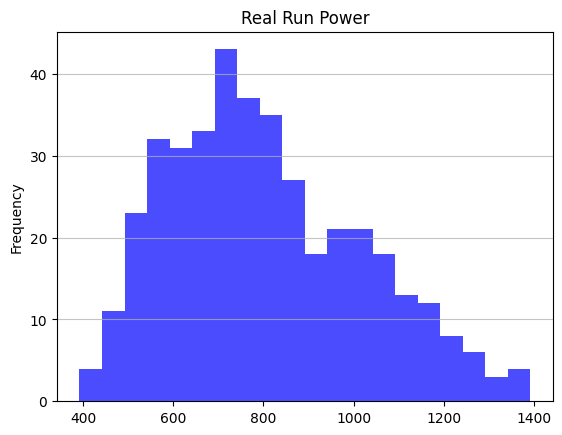

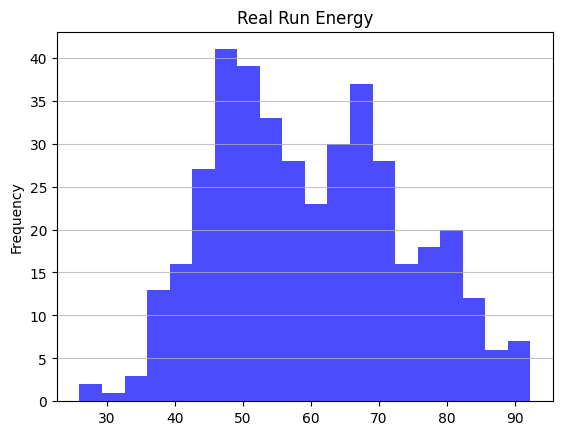

Power and Energy Results for len 512:
Async Power, energy: (np.float64(1254.7920303561796), np.float64(110.4162640370838)) W
No Async Power, energy: (np.float64(1427.3141624937236), np.float64(94.35953558772223)) W
Real Run Power, energy: (np.float64(803.5317379482623), np.float64(60.04406466136575)) W


In [38]:
async_p = get_power_async("/export2/obasit/ClusterLevelServing/vllm_logs/energy_profiler_logs/profiler_logs_prefill_power_tests/meta-llama/Llama-3.3-70B-Instruct/H100/1xTP4Prefill_1xTP4/inLen512_async_rpsinf/prefill_0_Oct22195715")
no_async_p = get_power_no_async("/export2/obasit/ClusterLevelServing/vllm_logs/energy_profiler_logs/profiler_logs_prefill_power_tests/meta-llama/Llama-3.3-70B-Instruct/H100/1xTP4Prefill_1xTP4/inLen512_noasync_rpsinf/prefill_0_Oct22195509")
real_p = get_power_real_run("/export2/obasit/ClusterLevelServing/vllm_logs/energy_profiler_logs/profiler_logs_prefill_power_tests/meta-llama/Llama-3.3-70B-Instruct/H100/1xTP4Prefill_1xTP4/inLen512_noasync_rps5/prefill_0_Oct22195932")

print("Power and Energy Results for len 512:")
print(f"Async Power, energy: {async_p} W")
print(f"No Async Power, energy: {no_async_p} W")
print(f"Real Run Power, energy: {real_p} W")

[np.float64(1275.3932772232768), np.float64(1176.6231937785606), np.float64(1232.3098590112627), np.float64(1319.276064798912), np.float64(717.7004938054923), np.float64(1283.489573740038), np.float64(705.4361280873148), np.float64(1249.6739537714795), np.float64(1203.997368952164), np.float64(658.1379738861939), np.float64(1332.0576035933718), np.float64(1402.5514446015106), np.float64(1354.247105794398), np.float64(1066.9768031005183), np.float64(1435.2670184286349), np.float64(729.854712452182), np.float64(1338.2623261387826), np.float64(1460.99996580053), np.float64(1457.208689621208), np.float64(1127.739709391623), np.float64(1223.5401473189831), np.float64(1270.664564369779), np.float64(665.5691289819625), np.float64(1314.9490882774762), np.float64(1324.8108847575393), np.float64(701.9648617975363), np.float64(1438.2934795796364), np.float64(1200.864703905589), np.float64(1408.6916359399493), np.float64(1462.8836890664277), np.float64(665.2005050015478), np.float64(1336.495610444

/tmp/ipykernel_497800/3542002045.py:19: RuntimeWarning: invalid value encountered in scalar divide
  return energy_j / compute_duration, energy_j


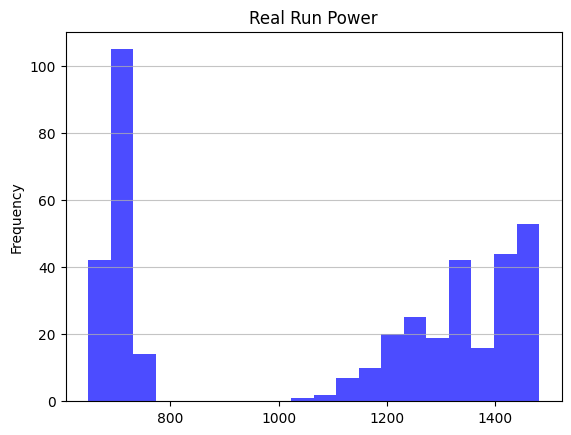

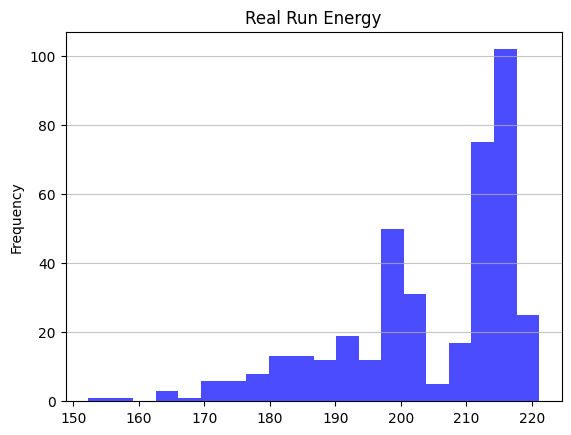

Power and Energy Results for len 1500:
Async Power, energy: (np.float64(1446.6400536882225), np.float64(248.5322242480368)) W
No Async Power, energy: (np.float64(1553.1992799737766), np.float64(231.63142822505887)) W
Real Run Power, energy: (np.float64(1087.2188199265993), np.float64(204.37402084093358)) W


In [39]:
async_p = get_power_async("/export2/obasit/ClusterLevelServing/vllm_logs/energy_profiler_logs/profiler_logs_prefill_power_tests/meta-llama/Llama-3.3-70B-Instruct/H100/1xTP4Prefill_1xTP4/inLen1500_async_rpsinf/prefill_0_Oct22200522")
no_async_p = get_power_no_async("/export2/obasit/ClusterLevelServing/vllm_logs/energy_profiler_logs/profiler_logs_prefill_power_tests/meta-llama/Llama-3.3-70B-Instruct/H100/1xTP4Prefill_1xTP4/inLen1500_noasync_rpsinf/prefill_0_Oct22200231")
real_p = get_power_real_run("/export2/obasit/ClusterLevelServing/vllm_logs/energy_profiler_logs/profiler_logs_prefill_power_tests/meta-llama/Llama-3.3-70B-Instruct/H100/1xTP4Prefill_1xTP4/inLen1500_noasync_rps5/prefill_0_Oct22200811")

print("Power and Energy Results for len 1500:")
print(f"Async Power, energy: {async_p} W")
print(f"No Async Power, energy: {no_async_p} W")
print(f"Real Run Power, energy: {real_p} W")

[np.float64(1499.743484685607), np.float64(1387.9966175483514), np.float64(1431.1516827478902), np.float64(1486.9962426281188), np.float64(1443.6037473749159), np.float64(1476.1488370320667), np.float64(1439.6049229311693), np.float64(1415.3455504305073), np.float64(1517.8507882421254), np.float64(1433.453252198679), np.float64(1381.9845519972769), np.float64(1423.4623967978164), np.float64(1428.5213232750327), np.float64(1463.192429473281), np.float64(792.9059326595511), np.float64(790.2625154257748), np.float64(1579.0208931175166), np.float64(1448.9549313586945), np.float64(1455.2449707526307), np.float64(1433.1888100796914), np.float64(1427.298588573719), np.float64(1446.735554553635), np.float64(1512.7531519972645), np.float64(1438.5952177353254), np.float64(788.9127826412634), np.float64(1433.7225235525705), np.float64(777.8805084695591), np.float64(1457.0960242774495), np.float64(1443.8028535721253), np.float64(1411.436168327204), np.float64(1476.837276235903), np.float64(1463.11

/tmp/ipykernel_497800/3542002045.py:19: RuntimeWarning: invalid value encountered in scalar divide
  return energy_j / compute_duration, energy_j


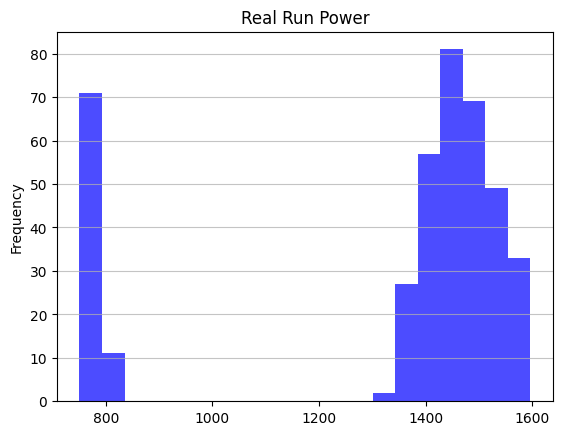

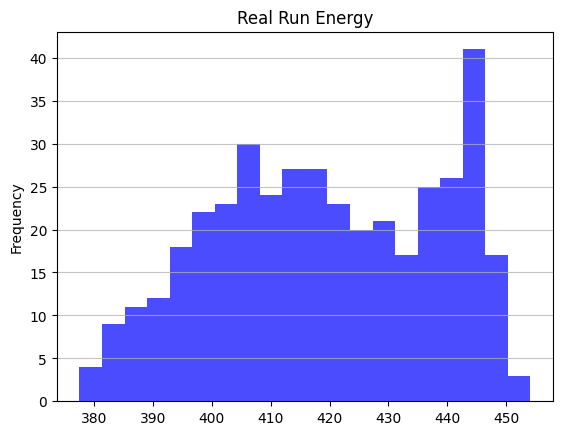

Power and Energy Results for len 3000:
Async Power, energy: (np.float64(1605.8518867022017), np.float64(487.0246149789883)) W
No Async Power, energy: (np.float64(1656.904959964192), np.float64(466.28178504795824)) W
Real Run Power, energy: (np.float64(1327.0089625619312), np.float64(419.31176230360745)) W


In [40]:
async_p = get_power_async("/export2/obasit/ClusterLevelServing/vllm_logs/energy_profiler_logs/profiler_logs_prefill_power_tests/meta-llama/Llama-3.3-70B-Instruct/H100/1xTP4Prefill_1xTP4/inLen3000_async_rpsinf/prefill_0_Oct23003004")
no_async_p = get_power_no_async("/export2/obasit/ClusterLevelServing/vllm_logs/energy_profiler_logs/profiler_logs_prefill_power_tests/meta-llama/Llama-3.3-70B-Instruct/H100/1xTP4Prefill_1xTP4/inLen3000_noasync_rpsinf/prefill_0_Oct23002632")
real_p = get_power_real_run("/export2/obasit/ClusterLevelServing/vllm_logs/energy_profiler_logs/profiler_logs_prefill_power_tests/meta-llama/Llama-3.3-70B-Instruct/H100/1xTP4Prefill_1xTP4/inLen3000_noasync_rps1/prefill_0_Oct23003346")

print("Power and Energy Results for len 3000:")
print(f"Async Power, energy: {async_p} W")
print(f"No Async Power, energy: {no_async_p} W")
print(f"Real Run Power, energy: {real_p} W")